# SNB 03 — Baseline Evaluation

Review standardized Forecasting metrics.

In [28]:
# Import libraries
from pathlib import Path
import sys
import matplotlib.pyplot as plt

In [20]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "seasonal_naive_baseline.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/seasonal_naive_baseline.yaml')

In [21]:
# Import module to run baseline model
from src.ontario_peak_risk.models.forecasting.seasonal_naive.run_baseline import (
    run_seasonal_naive_baseline,
)

In [22]:
# Run the baseline model - seasonal naive
results = run_seasonal_naive_baseline(CONFIG_PATH)


Seasonal Naive Forecasting baseline completed successfully.
Development folds evaluated: ['fold_2023', 'fold_2024']
Final 2025 holdout evaluated: NO
Reports: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\modeling\forecasting\seasonal_naive


In [23]:
# Display results
results["prediction_coverage"]

,fold,target,available_predictions,missing_predictions,coverage_pct,status
0,fold_2023,target_h01,52416,0,100.0,PASS
1,fold_2023,target_h02,52416,0,100.0,PASS
2,fold_2023,target_h03,52416,0,100.0,PASS
3,fold_2023,target_h04,52416,0,100.0,PASS
4,fold_2023,target_h05,52416,0,100.0,PASS
5,fold_2023,target_h06,52416,0,100.0,PASS
6,fold_2023,target_h07,52416,0,100.0,PASS
7,fold_2023,target_h08,52416,0,100.0,PASS
8,fold_2023,target_h09,52416,0,100.0,PASS
9,fold_2023,target_h10,52416,0,100.0,PASS


In [24]:
# Display results - Glabal metrics
results["global_metrics"]

,model,mae,rmse,mape,wape,bias,n_observations
0,seasonal_naive_daily,612.048608,994.292504,6.589649,6.726411,-0.837658,2519424


In [25]:
# Display results - Fold metrics
results["fold_metrics"]

,fold,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,603.791373,980.376647,6.509759,6.690513,-2.411334,1257984
1,fold_2024,620.283221,1007.978924,6.669319,6.761629,0.731706,1261440


In [26]:
# Display results - FSA metrics
results["fsa_metrics"]

,fold,fsa,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,L4T,841.011468,1285.375676,6.980937,7.438979,-2.480363,209664
1,fold_2023,M5R,505.767278,710.878568,6.647003,6.789390,-1.745842,209664
2,fold_2023,M5S,238.269779,328.552708,5.879423,5.976266,-0.656369,209664
3,fold_2023,M6G,736.067329,1080.302407,6.207034,6.343514,-2.530961,209664
4,fold_2023,M9R,460.031963,747.728341,7.676143,8.299188,-0.874014,209664
5,fold_2023,M9W,841.600423,1332.363841,5.668017,5.902156,-6.180456,209664
6,fold_2024,L4T,878.979744,1354.794878,7.200816,7.556773,1.176214,210240
7,fold_2024,M5R,507.305577,712.470111,6.688058,6.759015,1.211279,210240
8,fold_2024,M5S,241.226402,331.257869,6.006103,6.029931,0.514741,210240
9,fold_2024,M6G,758.428991,1096.993459,6.442644,6.489852,1.358294,210240


In [27]:
# Display results - Horizon metrics
results["horizon_metrics"]

,fold,horizon,target,mae,rmse,mape,wape,bias,n_observations
0,fold_2023,1,target_h01,603.977858,980.453728,6.512706,6.693444,-2.326877,52416
1,fold_2023,2,target_h02,603.966344,980.447671,6.512506,6.693259,-2.315364,52416
2,fold_2023,3,target_h03,603.937187,980.433109,6.512032,6.692890,-2.286207,52416
3,fold_2023,4,target_h04,603.902484,980.416834,6.511454,6.692460,-2.251503,52416
4,fold_2023,5,target_h05,603.870721,980.404928,6.510903,6.692059,-2.219740,52416
5,fold_2023,6,target_h06,603.844677,980.397301,6.510428,6.691715,-2.193697,52416
6,fold_2023,7,target_h07,603.823310,980.391651,6.510050,6.691416,-2.172329,52416
7,fold_2023,8,target_h08,603.811611,980.388878,6.509813,6.691219,-2.151408,52416
8,fold_2023,9,target_h09,603.805187,980.386958,6.509668,6.691068,-2.153627,52416
9,fold_2023,10,target_h10,603.780548,980.376953,6.509348,6.690695,-2.186909,52416


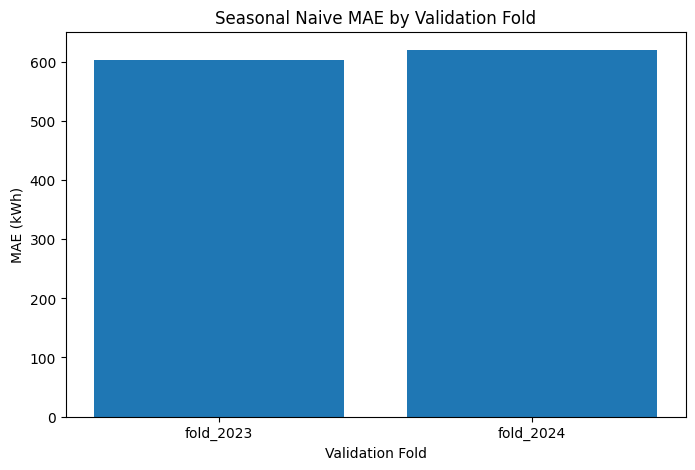

In [29]:
# Plot MAE by validation fold
fold_metrics = results["fold_metrics"]

plt.figure(figsize=(8, 5))

plt.bar(
    fold_metrics["fold"],
    fold_metrics["mae"],
)

plt.xlabel("Validation Fold")
plt.ylabel("MAE (kWh)")
plt.title("Seasonal Naive MAE by Validation Fold")

plt.show()

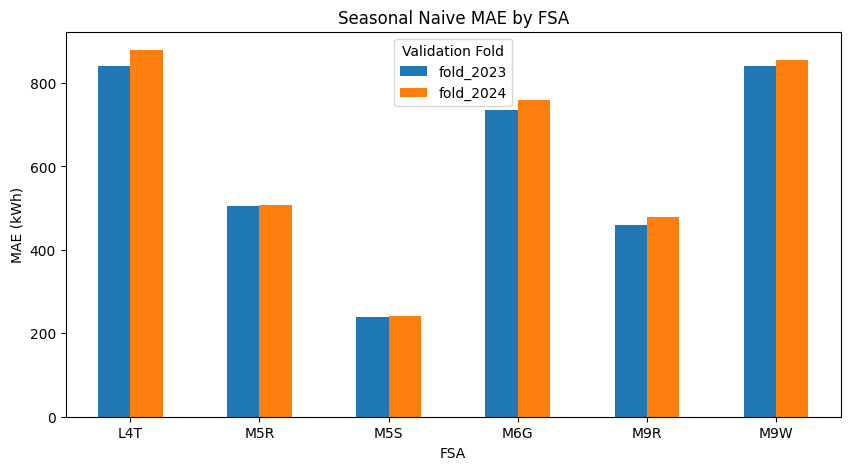

In [30]:
# Plot MAE by FSA and validation fold
fsa_metrics = results["fsa_metrics"]

pivot_fsa = fsa_metrics.pivot(
    index="fsa",
    columns="fold",
    values="mae",
)

pivot_fsa.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.xlabel("FSA")
plt.ylabel("MAE (kWh)")
plt.title("Seasonal Naive MAE by FSA")

plt.xticks(rotation=0)
plt.legend(title="Validation Fold")

plt.show()

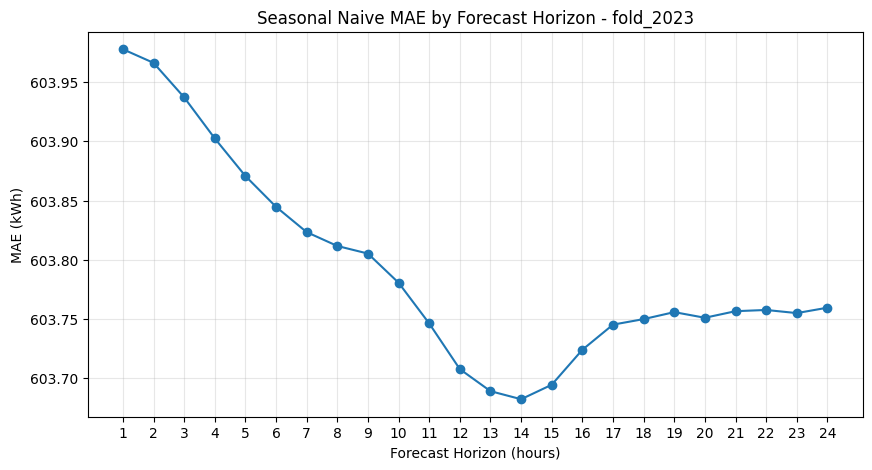

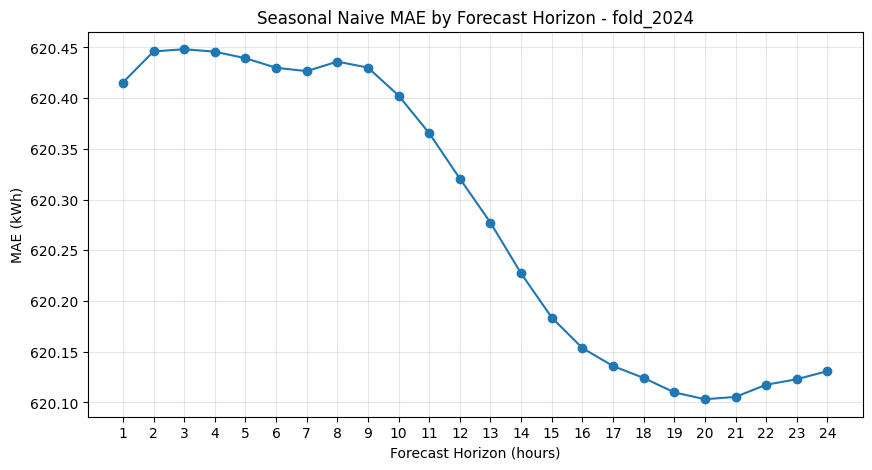

In [31]:
# Plot MAE by forecast horizon
horizon_metrics = results["horizon_metrics"]

for fold, group in horizon_metrics.groupby("fold"):
    plt.figure(figsize=(10, 5))

    plt.plot(
        group["horizon"],
        group["mae"],
        marker="o",
    )

    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("MAE (kWh)")
    plt.title(
        f"Seasonal Naive MAE by Forecast Horizon - {fold}"
    )

    plt.xticks(range(1, 25))
    plt.grid(alpha=0.3)

    plt.show()